In [1]:
# Modules
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb as db
import pandas as pd


In [ ]:
# Data loading

mr = db.query("SELECT * FROM 'mr.parquet'").df()


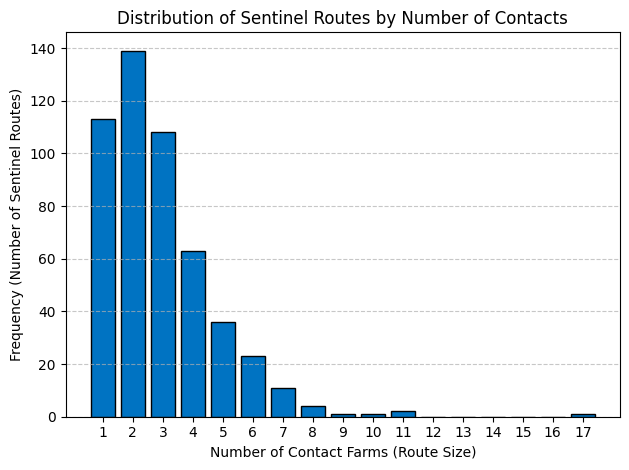

In [3]:
# Figure 1 - histogram showing the frequency of sentinel routes by their number of contact farms


unique_routes = mr[['bovine_id', 'route_size']].drop_duplicates()


max_val = int(unique_routes['route_size'].max())
bins = range(1, max_val + 2)


plt.hist(unique_routes['route_size'], 
         bins=bins, 
         edgecolor='black', 
         align='left', 
         color='#0073C2FF', 
         rwidth=0.8)


plt.xlabel('Number of Contact Farms (Route Size)')
plt.ylabel('Frequency (Number of Sentinel Routes)')
plt.title('Distribution of Sentinel Routes by Number of Contacts')


plt.xticks(range(1, max_val + 1))


plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.savefig('./graph/route_histogram.png')

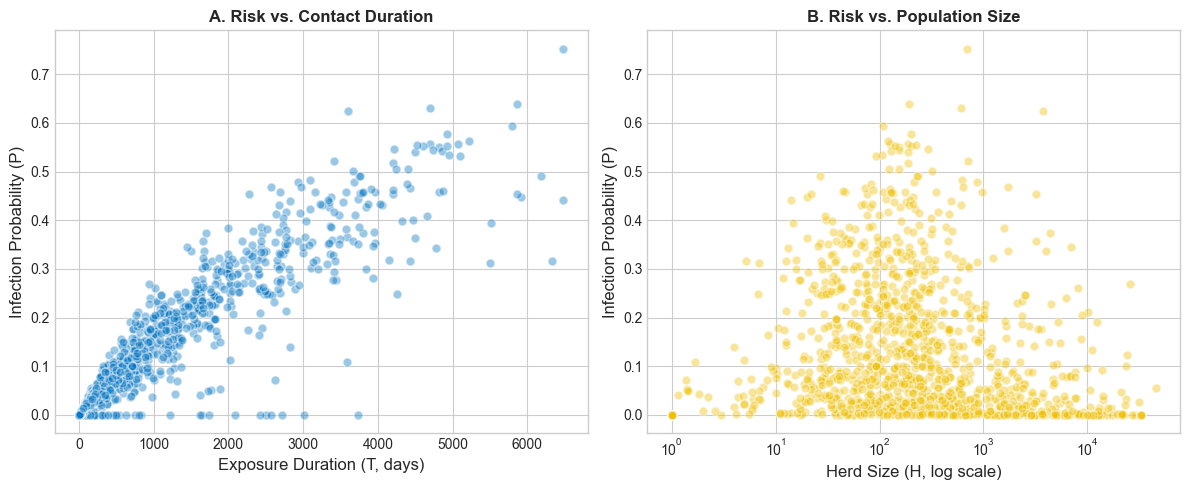

In [7]:
# Figure 2 Probability values using deterministic lambda


plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


scatter1 = ax1.scatter(mr['exposure_duration'], 
                       mr['p_deterministic'], 
                       alpha=0.4, color='#0073C2FF', edgecolors='w', s=40)
ax1.set_xlabel('Exposure Duration (T, days)', fontsize=12)
ax1.set_ylabel('Infection Probability (P)', fontsize=12)
ax1.set_title('A. Risk vs. Contact Duration', fontweight='bold')


scatter2 = ax2.scatter(mr['herd_size'], 
                       mr['p_deterministic'], 
                       alpha=0.4, color='#EFC000FF', edgecolors='w', s=40)
ax2.set_xscale('log')
ax2.set_xlabel('Herd Size (H, log scale)', fontsize=12)
ax2.set_ylabel('Infection Probability (P)', fontsize=12)
ax2.set_title('B. Risk vs. Population Size', fontweight='bold')

plt.tight_layout()
plt.savefig('./graph/p_dispersion_analysis.png', dpi=300)
plt.show()